In [ ]:
import os
import requests
import zipfile

# 1. Define the direct download link (Reliable backup source)
url = "https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip"
zip_name = "dataset-resized.zip"

print(f"Downloading {zip_name}...")

# 2. Download the file
response = requests.get(url, stream=True)
with open(zip_name, 'wb') as f:
    for chunk in response.iter_content(chunk_size=1024):
        if chunk:
            f.write(chunk)

print("Download complete. Unzipping...")

# 3. Unzip it
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("trash_data")

# 4. Define the new correct path
# The unzipped folder usually creates a structure like 'dataset-resized/glass/...'
base_dir = "trash_data/dataset-resized"

if os.path.exists(base_dir):
    print("\n✅ SUCCESS! Images are ready.")
    print("Categories found:", os.listdir(base_dir))
else:
    print("\n❌ Error: Folder still not found. Let's check what was unzipped:")
    print(os.listdir("trash_data"))

Download complete. Unzipping...

✅ SUCCESS! Images are ready.
Categories found: ['trash', 'glass', 'paper', 'metal', 'plastic', '.DS_Store', 'cardboard']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
data_dir = 'trash_data/dataset-resized'

In [ ]:
print("Loading Training DAta:")
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Loading Training DAta:
Found 2024 images belonging to 6 classes.


In [ ]:
print("\nLoading Validation Data:")
validation_genrator = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Loading Validation Data:
Found 503 images belonging to 6 classes.


In [ ]:
train_generator.samples

2024

In [ ]:
validation_genrator.samples

503

In [ ]:
print("\nCategories found:", train_generator.class_indices)


Categories found: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


In [ ]:
model = Sequential([
    Input(shape=(224,224,3)),#imagesize,color
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Flatten(),#Flatten Images
    Dense(512, activation='relu'),#neural network with 512 neurons
    Dropout(0.5),
    Dense(6, activation='softmax')#6 neuron (1 for each category)
])

In [ ]:
model.compile(
    loss='categorical_crossentropy',# The standard error formula for multi-class problems
    optimizer ='adam',# The algorithm that updates the brain (very popular/efficient)
    metrics=['accuracy']# We want to see the % accuracy score
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    88,605,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,980,870 (339.44 MB)

 Trainable params: 88,979,974 (339.43 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
print("Starting training ...(This may take a few miutes)")
history = model.fit(
    train_generator,#Study Materials
    epochs= 15,#Number of Study Materials
    validation_data=validation_genrator#Test Materials
)

Starting training ...(This may take a few miutes)
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 407ms/step - accuracy: 0.4259 - loss: 59.1959 - val_accuracy: 0.2386 - val_loss: 43.3422
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.5030 - loss: 16.1879 - val_accuracy: 0.2425 - val_loss: 36.2023
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.4664 - loss: 7.2505 - val_accuracy: 0.2107 - val_loss: 28.4904
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.4649 - loss: 4.9985 - val_accuracy: 0.2127 - val_loss: 19.6937
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.5020 - loss: 2.8010 - val_accuracy: 0.2286 - val_loss: 11.5287
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.4847 - loss: 2.0986 - val_accuracy: 0.2465 - val_loss: 8.6264
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.4891 - loss: 1.9674 - val_accuracy: 0.2406 - val_loss: 6.1672
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


In [ ]:
path = 'test.jpg'
try:
  img = image.load_img(path, target_size=(224,224))
  x = image.img_to_array(img)#img to list of numbers
  x=x/255.0
  x = np.expand_dims(x, axis=0)
  prediction = model.predict(x)
  class_names = list(train_generator.class_indices.keys())#list of materials
  predicted_class = class_names[np.argmax(prediction)]
  confidence = np.max(prediction)*100
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"prediction:{predicted_class} ({confidence:.1f}%)")
  plt.show()
except Exception as e:
  print(f"Error: Could mot load image '{path} . Did you upload it correctly?")
  print(f"Error: {e}")

Error: Could mot load image 'test.jpg . Did you upload it correctly?
Error: [Errno 2] No such file or directory: 'test.jpg'


In [ ]:
# Save the trained model to a file
model.save('my_waste_sorter.h5')

print("✅ Model saved as 'my_waste_sorter.h5'")

✅ Model saved as 'my_waste_sorter.h5'


Please upload your image now...


Saving metal100.jpg to metal100 (1).jpg
received: metal100 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


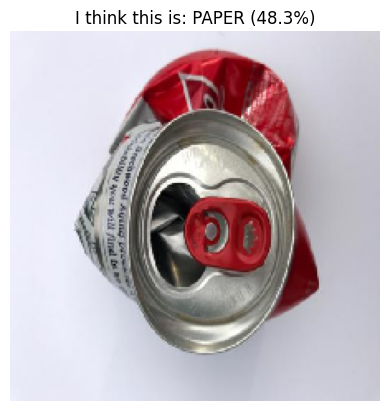

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. This creates a button to upload files
print("Please upload your image now...")
uploaded = files.upload()

# 2. Get the name of the file you just uploaded
filename = list(uploaded.keys())[0]
print(f"received: {filename}")

# 3. Load and Predict
img = image.load_img(filename, target_size=(224, 224))
x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

prediction = model.predict(x)
class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# 4. Show Result
plt.imshow(img)
plt.axis('off')
plt.title(f"I think this is: {predicted_class.upper()} ({confidence:.1f}%)")
plt.show()

In [ ]:
from tensorflow.keras.models import Model # Use functional API for transfer learning
from tensorflow.keras.layers import  GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2 # Import pre-trained model

In [ ]:
# Load the MobileNetV2 model pre-trained on ImageNet, without the top classification layer
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base model layers so they are not trained initially
base_model.trainable = False

# Add custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces spatial dimensions to a single vector
x = Dense(128, activation='relu')(x)
x = Dropout(0.8)(x)
predictions = Dense(6, activation='softmax')(x)


model1 = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
adam_optimizer = Adam(learning_rate=0.0004)

model1.compile(
    loss='categorical_crossentropy',
    optimizer=adam_optimizer,
    metrics=['accuracy']
)

print("Starting training ...(This may take a few miutes)")
history = model1.fit(
    train_generator,
    epochs= 30,
    validation_data=validation_genrator,
    batch_size=64,
    verbose=1
)

Starting training ...(This may take a few miutes)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 305ms/step - accuracy: 0.3646 - loss: 1.7087 - val_accuracy: 0.5984 - val_loss: 1.1690
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.5366 - loss: 1.2485 - val_accuracy: 0.6481 - val_loss: 0.9375
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.6003 - loss: 1.0716 - val_accuracy: 0.6839 - val_loss: 0.8337
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6467 - loss: 0.9602 - val_accuracy: 0.7018 - val_loss: 0.7637
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.6759 - loss: 0.8863 - val_accuracy: 0.7177 - val_loss: 0.7386
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6868 - loss: 0.8257 - val_accuracy: 0.7217 - val_loss: 0.7109
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.7060 - loss: 0.7789 - val_accuracy: 0.7276 - val_loss: 0.6922
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accura

Please upload your images now...


Saving t1.webp to t1 (1).webp
Saving p2.jpg to p2 (1).jpg
Saving m1.jpeg to m1 (2).jpeg
Saving b1.jpg to b1 (3).jpg
Saving metal100.jpg to metal100 (4).jpg
Saving g2.jpg to g2 (3).jpg
Saving paper100.jpg to paper100 (4).jpg

Processing: t1 (1).webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


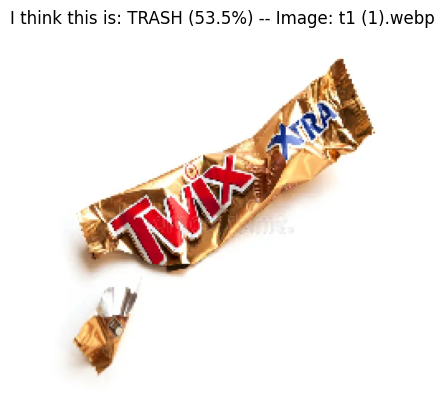


Processing: p2 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


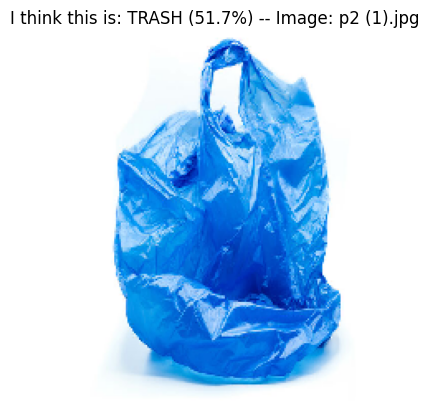


Processing: m1 (2).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


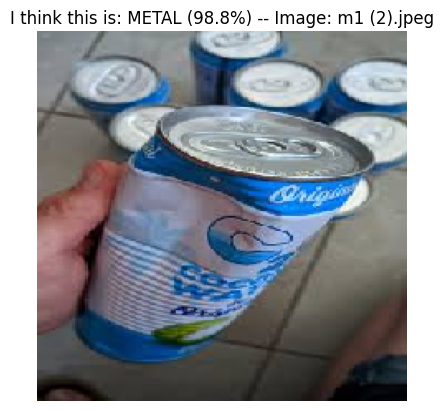


Processing: b1 (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


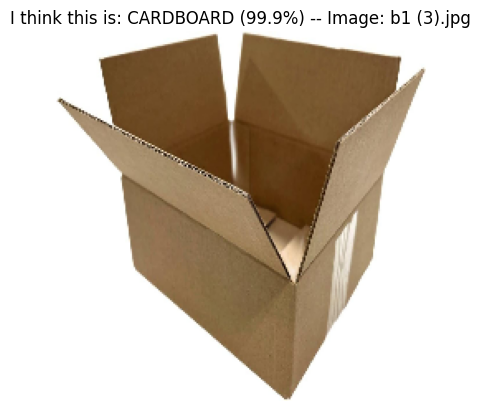


Processing: metal100 (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


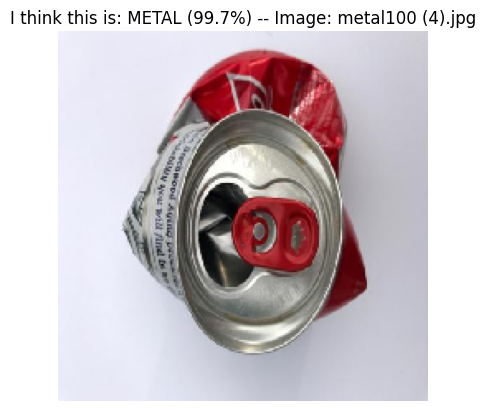


Processing: g2 (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


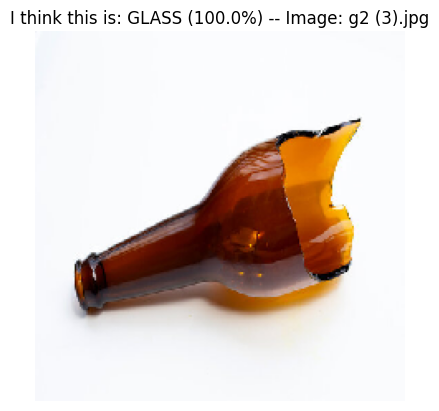


Processing: paper100 (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


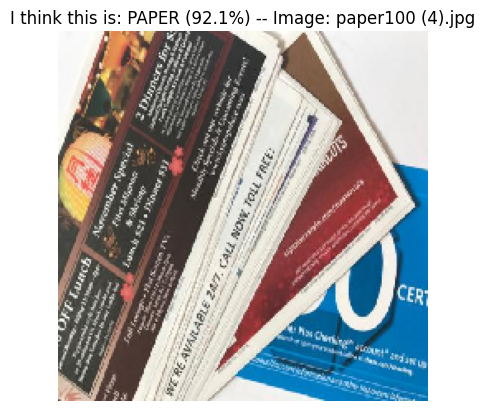

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. This creates a button to upload files
print("Please upload your images now...")
uploaded = files.upload()

# 2. Iterate through each uploaded file
for filename in uploaded.keys():
    print(f"\nProcessing: {filename}")

    # 3. Load and Predict
    img = image.load_img(filename, target_size=(224, 224))
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    prediction = model1.predict(x)
    class_names = list(train_generator.class_indices.keys())
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # 4. Show Result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"I think this is: {predicted_class.upper()} ({confidence:.1f}%) -- Image: {filename}")
    plt.show()